```
<14_person_collecting_waste.ipynb>

제미나이 의존도: 0-10%

이번엔 쓰레기 줍는 사람을 주제로 한 데이터셋인데, json에 정보가 담겨있는 객체탐지 데이터셋이다.
기억을 더듬어가며 코드를 짜다보니 제미나이의 도움을 거의 받지 않았다.
json도.. 알고 보면 사실은 딕셔너리이기 때문에, 겁먹을 이유가 없었다.
데이터가 많이 없어서 에폭을 30번 돌렸다.
구글에서 '쓰레기 줍는 사람'이라고 검색하고 그 이미지로 모델 테스트를 해봤는데, 잘 된다. 신기하다.. 매번 하는데도 신기하다.
```

In [27]:
import os
import json
import shutil
from ultralytics import YOLO
import time
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [17]:
# print(data.keys())
# dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])

# print(data['categories'])
# [{'id': 0, 'name': 'person-collecting-waste', 'supercategory': 'none'}, 
#  {'id': 1, 'name': 'person-collecting-waste', 'supercategory': 'person-collecting-waste'}]

# {'id': 0, 
#  'license': 1, 
#  'file_name': 'istockphoto-1414876469-612x612_jpg.rf.fbe83cab4bc2e1da4975bbb4ba109c3e.jpg', 
#  'height': 640, 
#  'width': 640, 
#  'date_captured': '2025-03-08T05:21:29+00:00', 
#  'extra': {'name': 'istockphoto-1414876469-612x612.jpg'}}

# {'id': 0, 
#  'image_id': 0, 
#  'category_id': 1, 
#  'bbox': [38, 63, 298, 521], 
#  'area': 155258, 'segmentation': [], 'iscrowd': 0}

common_path = 'dataset/person_collecting_waste/person-collecting-waste-coco-dataset'

split_data = ['train', 'valid', 'test']

for split_type in split_data:
    txt_save_path = os.path.join(common_path, f'{split_type}_labels')
    os.makedirs(txt_save_path, exist_ok=True)
    
    json_dir = os.path.join(common_path, f'{split_type}/_annotations.coco.json')
    with open(json_dir, 'r', encoding='utf-8') as f:
        data = json.load(f)

    image_dict = {}
    images = data['images']
    for image in images:
        image_id = image['id']
        file_name = image['file_name']
        height = image['height']
        width = image['width']
        image_dict[image_id] = (file_name, height, width)


    labels_per_image = {}
    annotations = data['annotations']
    for anno in annotations:
        image_id = anno['image_id']
    
        if image_id not in labels_per_image.keys():
            labels_per_image[image_id] = []
    
        file_name, img_height, img_width = image_dict[image_id]
    
        xmin, ymin, box_w, box_h = anno['bbox']
    
        cat_id = anno['category_id'] - 1
    
        x_center = xmin + (box_w / 2)
        y_center = ymin + (box_h / 2)
    
        norm_x = x_center / img_width
        norm_y = y_center / img_height
        norm_w = box_w / img_width
        norm_h = box_h / img_height
    
        line = f'{cat_id} {norm_x:.6f} {norm_y:.6f} {norm_w:.6f} {norm_h:.6f}'
        labels_per_image[image_id].append(line)

    for image_id, lines in labels_per_image.items():
        file_name, _, _ = image_dict[image_id]
        
        pure_name, ext = os.path.splitext(file_name)
        txt_name = f'{pure_name}.txt'
        full_txt_save_path = os.path.join(txt_save_path, txt_name)
        with open(full_txt_save_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(lines) + '\n')

print('finished')

finished


In [23]:
parent_dir = 'dataset/person_collecting_waste'
for split_type in split_data:
    count = 0
    dest_image_path = os.path.join(parent_dir, f'{split_type}/images')
    dest_label_path = os.path.join(parent_dir, f'{split_type}/labels')
    os.makedirs(dest_image_path, exist_ok=True)
    os.makedirs(dest_label_path, exist_ok=True)

    src_image_path = os.path.join(parent_dir, f'person-collecting-waste-coco-dataset/{split_type}')
    src_image_list = [f for f in os.listdir(src_image_path) if f.endswith(('.jpg', '.jpeg', '.png', '.webp'))]
    set_src_image = set(src_image_list)
    
    src_label_path = os.path.join(parent_dir, f'person-collecting-waste-coco-dataset/{split_type}_labels')
    src_label_list = [f for f in os.listdir(src_label_path) if f.endswith(('.txt'))]
    set_src_label = set(src_label_list)

    for image in set_src_image:
        pure_name, ext = os.path.splitext(image)
        txt_name = f'{pure_name}.txt'
        if txt_name in set_src_label:
            full_src_image_path = os.path.join(src_image_path, image)
            full_dest_image_path = os.path.join(dest_image_path, image)
            shutil.copy(full_src_image_path, full_dest_image_path)

            full_src_label_path = os.path.join(src_label_path, txt_name)
            full_dest_label_path = os.path.join(dest_label_path, txt_name)
            shutil.copy(full_src_label_path, full_dest_label_path)
            count += 1

    print(f'{split_type} count: {count}')

train count: 210
valid count: 45
test count: 45


In [24]:
yaml_path = 'dataset/person_collecting_waste/data.yaml'
with open(yaml_path, 'w', encoding='utf-8') as f:
    f.write('train: ../train/images\n')
    f.write('val: ../valid/images\n')
    f.write('test: ../test/images\n')
    f.write('\n')
    f.write('nc: 1\n')
    f.write("names: ['person-collecting-waste']")

In [26]:
model = YOLO('yolov8n.pt')

current_dir = os.getcwd()

start_time = time.time()

model.train(
    data=yaml_path, 
    epochs=30, 
    imgsz=640, 
    device='mps', 
    project=os.path.join(current_dir, 'runs'), 
    name='person_collecting_waste'
)

elapsed_time = int(time.time() - start_time)
mins, secs = divmod(elapsed_time, 60)
print(f'{mins}:{secs}')

New https://pypi.org/project/ultralytics/8.4.106 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/person_collecting_waste/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=per

In [28]:
def inspect_detection(image_path, conf_threshold=0.4, iou_threshold=0.5):
    model = YOLO('runs/person_collecting_waste/weights/best.pt')
    preds = model.predict(
        source=image_path, 
        conf=conf_threshold, 
        iou=iou_threshold, 
        device='mps'
    )

    result = preds[0]
    annotated_img_bgr = result.plot()
    img_rgb = cv2.cvtColor(annotated_img_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.title(f'Conf: {conf_threshold} | IoU: {iou_threshold}')
    plt.axis('off')
    plt.show()


image 1/1 /Users/jeongjaehun/Github/03_object_detection/dataset/1809_2896_1515.jpg: 448x640 2 person-collecting-wastes, 207.4ms
Speed: 4.3ms preprocess, 207.4ms inference, 36.3ms postprocess per image at shape (1, 3, 448, 640)


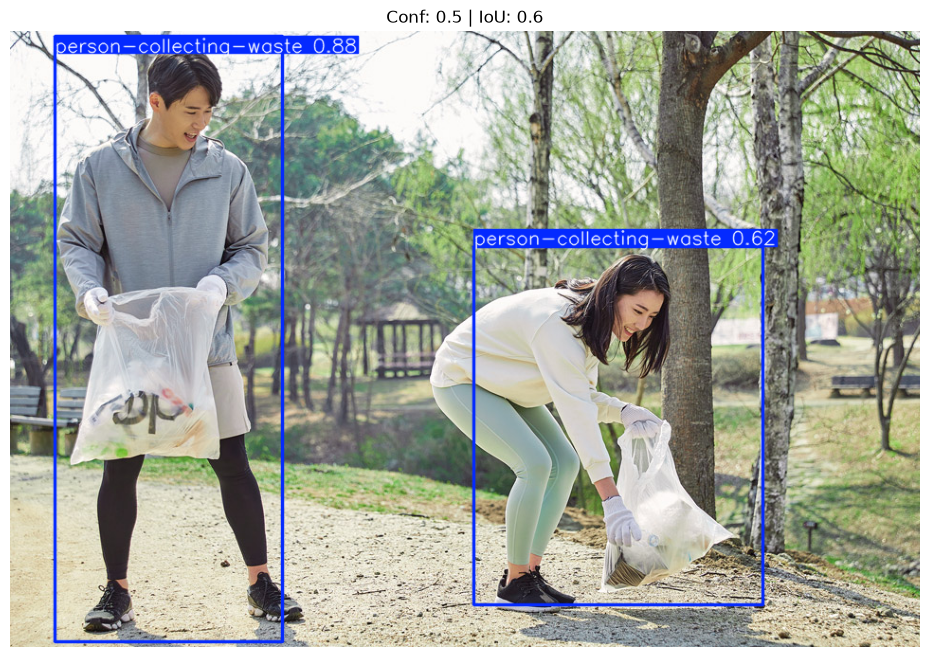

In [34]:
image_path = 'dataset/1809_2896_1515.jpg'
inspect_detection(image_path, conf_threshold=0.5, iou_threshold=0.6)